# Imports:

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from ase.io import Trajectory
from ase.visualize import view
from pymatgen.io.ase import AseAtomsAdaptor
import seaborn as sns
import matplotlib.pyplot as plt
col_list = sns.color_palette("tab10", 100)

import tqdm

import os
from aq_gnome import (
    Data_Handler,
    plot_periodic_table_with_values, get_col_dict_for_atoms,
    Stable_Entries, Stability_Criteria, get_simplified_df,
    atoms_from_db, Compound_HHI_scores, sys_in_MP_db
)
# pHs = np.linspace(-2, 16, 19) # Data specific
# Us = np.linspace(-2, 4, 31) # Data specific

# Database setup:

In [13]:
# Define directory of data (can be left as None if the data folder is in 
# the package root):
dir_of_data = None

dh = Data_Handler(
# Whether to apply solid filter:
    solid_filter = True, 
# Whether to use only GGA calculations (True), or include r2SCAN data via the MP-mixing scheme (False):
    gga_only = False,
# Path to data directory:
    path_to_data_directory = dir_of_data
    )

# Inclusion/exclusion of elements:

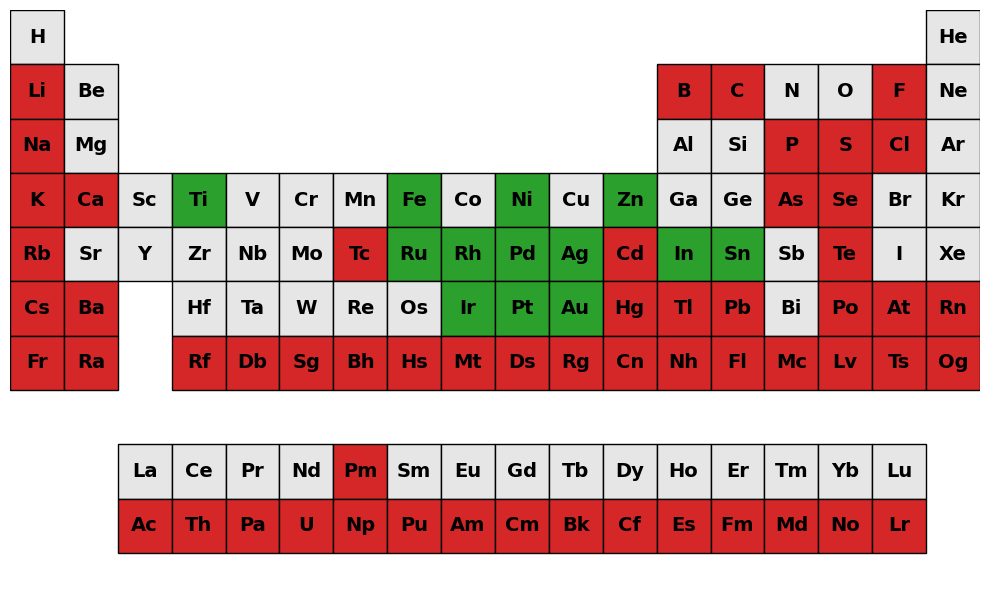

In [14]:
radioactive_elements = ['Tc',  'Ra', 'Rf', 'Db', 'Sg', 'Bh', 'Hs',
                        'Mt', 'Ds', 'Rg', 'Cn', 'Nh', 'Fl', 'Mc', 'Lv',
                        'Ts', 'Og', 'Pm', 'Ac', 'Th', 'Pa', 'U', 'Np', 
                        'Pu', 'Am', 'Cm', 'Bk', 'Cf', 'Es', 'Fm', 'Md',
                        'No', 'Lr', 'Po', 'At', 'Rn'
                        ]
reactive_with_water_elements = ['Li', 'Na', 'K', 'Rb', 'Cs', 'Fr', 'Ca', 'Ba']

toxic_elements = ['Tl', 'Pb', 'As', 'Cd', 'Hg']

too_rare_elements = ['Be', 'Y', 'Nb', 'Rh', 'Pd', 'Te', 'Sb', 'Lu', 'Re',
                    'Os', 'Pt', 'Hg', 'Bi', 'La', 'Ce', 'Pr', 'Nd', 'Pm',
                    'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb',
                    'Ru', 'Ir']

strong_binding_elements = ['Ti', 'Ni', 'Pd', 'Pt', 'Ru', 'Rh', 'Ir', 'Fe'] # 'Ga'
weak_binding_elements = ['Zn', 'Ag', 'Au', 'Cd', 'In', 'Sn', 'Hg', 'Tl', 'Pb']


CMR = [
    'Be', 'B', 'Si', 'Sc', 'Ti', 'V', 'Co', 'Ga', 'Ge', 'Cr', 'Y', 'Nb', 
    'Ru', 'Rh', 'Pd', 'Sb', 'Lu', 'Hf', 'Ta', 'W', 'Os', 'Ir', 'Pt', 'Bi',
    'La', 'Ce', 'Pr', 'Nd', 'Pm', 'Sm', 'Eu', 'Gd',
    'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb'
]


elements_to_exclude = radioactive_elements + toxic_elements + reactive_with_water_elements + ['P', 'F', 'Se', 'Te', 'B', 'C', 'S', 'Cl'] # elements to discart
elements_whic_must_be_included = weak_binding_elements + strong_binding_elements

plot_periodic_table_with_values(
    get_col_dict_for_atoms(elements_to_discard=elements_to_exclude, 
                           elements_to_include=elements_whic_must_be_included)
)

### Discarding materials based on element selection

In [15]:
dh.remove_entries_with_elements(elements_to_exclude)
dh.remove_entries_without_elements(elements_whic_must_be_included, False)

Number of entries removed: 283529 Number of entries left: 245442 which is 46.40% of total GNoME database
Removed all entries not containing any of the following elements: Zn, Ag, Au, Cd, In, Sn, Hg, Tl, Pb, Ti, Ni, Pd, Pt, Ru, Rh, Ir, Fe .Number of entries removed: 60439 Number of entries left: 185003 which is 34.97% of total GNoME database


### pbx stability criteria

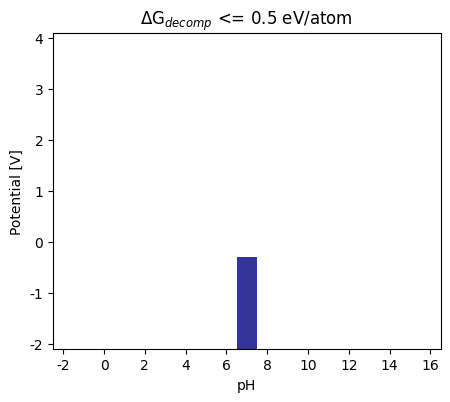

In [16]:
SCS = [Stability_Criteria(pHs=7, Us=[-4.13700000e-01, -2], decomposition_threshold=0.5),
       # Stability_Criteria(pHs=0, Us=[1.2, 1.6], decomposition_threshold=0.05),
       # Stability_Criteria(pHs=[2, 5], Us=[0., 2], decomposition_threshold=1),
       ]

for sc in SCS:
    sc.visualize()

In [17]:
se = Stable_Entries(dh, SCS)

Mixed GGA/GGA(+U)/r2SCAN results will be used for stability analysis.


In [18]:
from pymatgen.core import Composition

def is_balanced_groups(composition_str: str, 
                       group1: list[str], 
                       group2: list[str],
                       fractional_limit: float) -> bool:
    """Check if composition has equal atom counts from group1 and group2."""
    comp = Composition(composition_str)
    element_dict = comp.get_el_amt_dict()
    
    group1_count = sum(element_dict.get(el, 0) for el in group1)
    group2_count = sum(element_dict.get(el, 0) for el in group2)
    
    if group1_count == 0 or group2_count == 0:
        return False
    
    if np.isclose(fractional_limit, 0):
        return group1_count == group2_count
    else:
        diff = np.abs(group1_count - group2_count)
        ratio = diff / (group1_count + group2_count)
        return ratio <= fractional_limit
    

strong_binding_elements = ['Ti', 'Ni', 'Pd', 'Pt',  'Ru', 'Rh', 'Ir', 'Fe'] # 'Ga',
weak_binding_elements = ['Zn', 'Ag', 'Au', 'Cd', 'In', 'Sn', 'Hg', 'Tl', 'Pb']

In [19]:
df = se.get_stable_df()
df

100%|██████████| 185003/185003 [01:23<00:00, 2205.94it/s]


Found 3443 stable entries given the stability criteria.


,"max_dG_U[-2,-0.4137]_pH7",Composition,MaterialId,Reduced Formula,Elements,NSites,Volume,Density,Point Group,Space Group,...,Data Directory,gga_only_pbx_save_id,mixed_pbx_save_id,Disorder Probability,average_HHI_P,average_HHI_R,average_HHI_P_excluding_O_H,average_HHI_R_excluding_O_H,max_HHI_P,max_HHI_R
102,0.05,Fe6Rh12Sn1Zn5,000d543e89,Zn5Fe6SnRh12,"[Fe, Zn, Rh, Sn]",24,336.4078,9.9496,mmm,Pmmm,...,gs://crystal-design/output/borg/round_3_wy_3/1...,GGA_000d543e89,Not computed,0.906468,2642.0,4812.0,2642.0,4812.0,3200.0,8000.0
198,0.42,Cr1Pd2Pt4Ta1,00178dc38c,TaCr(PdPt2)2,"[Cr, Pd, Ta, Pt]",8,124.9705,16.2920,mm2,Pmm2,...,gs://crystal-design/output/borg/round_3_wy_3/1...,GGA_00178dc38c,r2S_00178dc38c,0.949892,4225.0,7662.0,4225.0,7662.0,5500.0,9100.0
336,0.15,Au4Bi2Sb6,0029f29b5d,BiSb3Au2,"[Sb, Au, Bi]",12,323.7794,9.9310,2,P2_1,...,gs://crystal-design/output/borg/improved_wy_ro...,GGA_0029f29b5d,GGA_0029f29b5d,0.860376,5200.0,3033.0,5200.0,3033.0,7900.0,6000.0
588,0.02,Pd11Zn9,00497dcb67,Zn9Pd11,"[Zn, Pd]",20,293.2266,9.9629,4/m,I4/m,...,gs://crystal-design/output/improved_mo_2/1e_3_...,GGA_00497dcb67,GGA_00497dcb67,0.590048,2480.0,5255.0,2480.0,5255.0,3200.0,8000.0
863,0.01,Au1Pd9Zn8,006852e6c3,Zn8Pd9Au,"[Zn, Pd, Au]",18,266.6462,10.4499,2/m,C2/m,...,gs://crystal-design/output/borg/round_3_wy_2/1...,GGA_006852e6c3,GGA_006852e6c3,0.977456,2372.0,4900.0,2372.0,4900.0,3200.0,8000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
528126,0.47,Cu3Nb4Pt9,ff969439a8,Nb4(CuPt3)3,"[Cu, Nb, Pt]",16,247.2340,15.5689,m,Pm,...,gs://crystal-design/output/borg/round_3_3/1e_3...,GGA_ff969439a8,GGA_ff969439a8,0.314099,5519.0,7600.0,5519.0,7600.0,8500.0,9100.0
528137,0.06,Pd1Rh2Ru1Sb12,ff97b7948c,Sb12PdRuRh2,"[Ru, Rh, Pd, Sb]",16,414.2038,7.5145,-1,P-1,...,gs://crystal-design/output/borg/round_3_wy_3/1...,GGA_ff97b7948c,GGA_ff97b7948c,0.995184,6725.0,4550.0,6725.0,4550.0,7900.0,8000.0
528416,0.36,Au1Pt3Sn4Zn6,ffb5ea9b1b,Zn6Sn4Pt3Au,"[Zn, Sn, Pt, Au]",14,270.7894,10.1152,-3m,P-3m1,...,gs://crystal-design/output/borg/improved_wy_3/...,GGA_ffb5ea9b1b,GGA_ffb5ea9b1b,0.695285,2686.0,3293.0,2686.0,3293.0,5500.0,9100.0
528634,0.04,Ag3Au4In1,ffd2a6d378,InAg3Au4,"[Ag, In, Au]",8,148.0132,13.7576,4/mmm,I4/mmm,...,gs://crystal-design/output/borg/round_3_wy_2/1...,GGA_ffd2a6d378,Not computed,0.927797,1412.0,1275.0,1412.0,1275.0,3300.0,2000.0


In [20]:
df = df[df['Composition'].apply(lambda x: is_balanced_groups(x, strong_binding_elements, weak_binding_elements,
                                                             fractional_limit=.5))]
df

,"max_dG_U[-2,-0.4137]_pH7",Composition,MaterialId,Reduced Formula,Elements,NSites,Volume,Density,Point Group,Space Group,...,Data Directory,gga_only_pbx_save_id,mixed_pbx_save_id,Disorder Probability,average_HHI_P,average_HHI_R,average_HHI_P_excluding_O_H,average_HHI_R_excluding_O_H,max_HHI_P,max_HHI_R
102,0.05,Fe6Rh12Sn1Zn5,000d543e89,Zn5Fe6SnRh12,"[Fe, Zn, Rh, Sn]",24,336.4078,9.9496,mmm,Pmmm,...,gs://crystal-design/output/borg/round_3_wy_3/1...,GGA_000d543e89,Not computed,0.906468,2642.0,4812.0,2642.0,4812.0,3200.0,8000.0
588,0.02,Pd11Zn9,00497dcb67,Zn9Pd11,"[Zn, Pd]",20,293.2266,9.9629,4/m,I4/m,...,gs://crystal-design/output/improved_mo_2/1e_3_...,GGA_00497dcb67,GGA_00497dcb67,0.590048,2480.0,5255.0,2480.0,5255.0,3200.0,8000.0
863,0.01,Au1Pd9Zn8,006852e6c3,Zn8Pd9Au,"[Zn, Pd, Au]",18,266.6462,10.4499,2/m,C2/m,...,gs://crystal-design/output/borg/round_3_wy_2/1...,GGA_006852e6c3,GGA_006852e6c3,0.977456,2372.0,4900.0,2372.0,4900.0,3200.0,8000.0
1616,0.00,Cu6Ga2Pt12Zn4,00c3a34221,Zn2Ga(CuPt2)3,"[Cu, Zn, Ga, Pt]",24,341.7145,15.1778,mmm,Pmmn,...,gs://crystal-design/output/borg/round_3_wy_3/1...,GGA_00c3a34221,Not computed,0.891557,3875.0,5400.0,3875.0,5400.0,5500.0,9100.0
2624,0.05,Ir1Ni4Pd7Sn8,013b39f6c8,Ni4Sn8IrPd7,"[Ni, Pd, Sn, Ir]",20,351.3542,10.0270,1,P1,...,gs://crystal-design/output/borg/round_3_wy_3/1...,GGA_013b39f6c8,GGA_013b39f6c8,0.953316,2635.0,4195.0,2635.0,4195.0,5500.0,9100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
521925,0.14,Mg1Rh12Sn6Zn5,fc9b2ef8ee,MgZn5(SnRh2)6,"[Mg, Zn, Rh, Sn]",24,374.7301,10.1852,mmm,Pmmm,...,gs://crystal-design/output/borg/round_3_wy_3/1...,GGA_fc9b2ef8ee,GGA_fc9b2ef8ee,0.902323,2804.0,4817.0,2804.0,4817.0,5300.0,8000.0
523101,0.05,Fe6Pt1Rh11Zn6,fd2cd7a47e,Zn6Fe6PtRh11,"[Fe, Zn, Rh, Pt]",24,330.1153,10.3348,mm2,Pmm2,...,gs://crystal-design/output/borg/round_3_wy_3/1...,GGA_fd2cd7a47e,r2S_fd2cd7a47e,0.913169,2696.0,4871.0,2696.0,4871.0,5500.0,9100.0
524592,0.44,Mg1Rh3Ru3Sn13,fde1cd280e,MgSn13(RuRh)3,"[Mg, Ru, Rh, Sn]",20,425.6076,8.5033,m,Cm,...,gs://crystal-design/output/borg/round_3_wy_3/1...,GGA_fde1cd280e,Not computed,0.994913,2915.0,3465.0,2915.0,3465.0,5300.0,8000.0
525772,0.15,Ga6Rh12Ti1Zn5,fe701f340c,TiZn5(GaRh2)6,"[Ti, Zn, Ga, Rh]",24,335.7390,10.0309,mmm,Pmmm,...,gs://crystal-design/output/borg/round_3_wy_3/1...,GGA_fe701f340c,GGA_fe701f340c,0.859154,3354.0,4938.0,3354.0,4938.0,5500.0,8000.0


In [21]:
df = df[df["Disorder Probability"] < 0.5]
# df = df[df['NSites'] < 40]
print(len(df))
get_simplified_df(df)


55


,"max_dG_U[-2,-0.4137]_pH7",Composition,MaterialId,Reduced Formula,Elements,NSites,Crystal System,Dimensionality Cheon,Bandgap,Disorder Probability,average_HHI_P,average_HHI_R,average_HHI_P_excluding_O_H,average_HHI_R_excluding_O_H,max_HHI_P,max_HHI_R
14706,0.07,Rh4Sb1Zn3,0713f94e7e,Zn3SbRh4,"[Zn, Rh, Sb]",8,trigonal,3D,0.0215,0.329718,3188.0,5138.0,3188.0,5138.0,7900.0,8000.0
16320,0.25,Rh3Zn5,07dfec17cd,Zn5Rh3,"[Zn, Rh]",8,orthorhombic,3D,0.0054,0.495256,2200.0,4188.0,2200.0,4188.0,3200.0,8000.0
30379,0.00,Ga1Pd10Zn5,0e99b634a1,Zn5GaPd10,"[Zn, Ga, Pd]",16,monoclinic,3D,0.0115,0.300423,2844.0,5712.0,2844.0,5712.0,5500.0,8000.0
30890,0.24,Ho1In8Rh9,0ed572c242,HoIn8Rh9,"[Rh, In, Ho]",18,trigonal,3D,NaN,0.452691,3594.0,5061.0,3594.0,5061.0,9500.0,8000.0
32624,0.45,Pd20Sn12Sr4,0fa25fdbc8,SrSn3Pd5,"[Sr, Pd, Sn]",36,orthorhombic,intercalated ion,NaN,0.420387,3111.0,5311.0,3111.0,5311.0,4200.0,8000.0
36110,0.26,H6In2Ni6,1161ea672e,In(NiH)3,"[H, Ni, In]",14,cubic,3D,0.0239,0.026577,NaN,NaN,1575.0,1625.0,NaN,NaN
49870,0.00,Cu1In2Pt5,1817c5b0ae,In2CuPt5,"[Cu, In, Pt]",8,tetragonal,3D,0.0036,0.361664,4462.0,6375.0,4462.0,6375.0,5500.0,9100.0
106537,0.42,Pd4Sn4Zn6,338557731e,Zn3(SnPd)2,"[Zn, Pd, Sn]",14,hexagonal,3D,0.0097,0.411732,2343.0,3557.0,2343.0,3557.0,3200.0,8000.0
109649,0.00,Au3In4Pd9,3501a60a63,In4(Pd3Au)3,"[Pd, In, Au]",16,tetragonal,3D,0.0072,0.338480,2831.0,5188.0,2831.0,5188.0,3300.0,8000.0
130114,0.00,In1Pt6Sn1,3ef06dfc16,InSnPt6,"[In, Sn, Pt]",8,cubic,3D,0.0041,0.412070,4862.0,7275.0,4862.0,7275.0,5500.0,9100.0


> **Note on reproducibility — Materials Project database**
>
> This cell queries the **live** Materials Project API. As the MP database grows
> over time, future runs may yield fewer candidates than reported in the paper,
> if element systems that were novel at the time of publication are subsequently
> added to MP.


In [11]:
simp = sys_in_MP_db(os.environ["MP_API_KEY"])

df = df[~df['Elements'].apply(lambda x: simp.in_db(x))]
print(len(df))
df

Retrieving ThermoDoc documents: 100%|██████████| 116/116 [00:00<00:00, 809549.52it/s]
c:\Users\matnis\OneDrive - Danmarks Tekniske Universitet\Skrivebord\Projects\GNoME_aqueous_stability\.venv\Lib\site-packages\uncertainties\core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
Retrieving ThermoDoc documents: 100%|██████████| 64/64 [00:00<00:00, 1405421.24it/s]

13


,"max_dG_U[-2,-0.4137]_pH7",Composition,MaterialId,Reduced Formula,Elements,NSites,Volume,Density,Point Group,Space Group,...,Data Directory,gga_only_pbx_save_id,mixed_pbx_save_id,Disorder Probability,average_HHI_P,average_HHI_R,average_HHI_P_excluding_O_H,average_HHI_R_excluding_O_H,max_HHI_P,max_HHI_R
36110,0.26,H6In2Ni6,1161ea672e,In(NiH)3,"[H, Ni, In]",14,121.3645,8.0430,m-3m,Pm-3n,...,gs://crystal-design/output/borg/round_3_3/1e_3...,GGA_1161ea672e,GGA_1161ea672e,0.026577,NaN,NaN,1575.0,1625.0,NaN,NaN
106537,0.42,Pd4Sn4Zn6,338557731e,Zn3(SnPd)2,"[Zn, Pd, Sn]",14,261.9323,8.1969,6/mmm,P6_3/mmc,...,gs://crystal-design/output/borg/round_2_mo_3/1...,GGA_338557731e,r2S_338557731e,0.411732,2343.0,3557.0,2343.0,3557.0,3200.0,8000.0
154476,0.03,H2Rh12Sn8,4abcc9dc85,Sn4HRh6,"[H, Rh, Sn]",22,372.0783,9.7584,6/mmm,P6_3/mmc,...,gs://crystal-design/output/borg/round_2_mo_3/1...,GGA_4abcc9dc85,GGA_4abcc9dc85,0.402083,NaN,NaN,2960.0,5440.0,NaN,NaN
159636,0.01,Ga1Pt5Zn2,4d3d008439,Zn2GaPt5,"[Zn, Ga, Pt]",8,120.8989,16.1517,mmm,Cmmm,...,gs://crystal-design/output/borg/improved_wy_ro...,GGA_4d3d008439,r2S_4d3d008439,0.243778,4525.0,6400.0,4525.0,6400.0,5500.0,9100.0
173605,0.15,Au2Pd5V1,54010cfdcc,VPd5Au2,"[V, Pd, Au]",8,126.6097,12.8134,4/mmm,I4/mmm,...,gs://crystal-design/output/borg/round_5_3/1e_3...,GGA_54010cfdcc,GGA_54010cfdcc,0.408911,2688.0,5675.0,2688.0,5675.0,3300.0,8000.0
200009,0.08,H1Ni3Sn1,60cf57ffc5,Ni3SnH,"[H, Ni, Sn]",5,53.6653,9.1527,m-3m,Pm-3m,...,gs://crystal-design/output/borg/round_2_mo_3/1...,GGA_60cf57ffc5,r2S_60cf57ffc5,0.040272,NaN,NaN,1400.0,1525.0,NaN,NaN
208684,0.03,Pd8Sn3Zn1,650697ed6b,ZnSn3Pd8,"[Zn, Pd, Sn]",12,200.8482,10.5239,m,Pm,...,gs://crystal-design/output/borg/improved_wy_ro...,GGA_650697ed6b,r2S_650697ed6b,0.446303,2917.0,5892.0,2917.0,5892.0,3200.0,8000.0
268027,0.12,H1In1Ni3,81d1bef2cd,InNi3H,"[H, Ni, In]",5,53.4503,9.0686,m-3m,Pm-3m,...,gs://crystal-design/output/borg/round_2_mo_3/1...,GGA_81d1bef2cd,r2S_81d1bef2cd,0.039997,NaN,NaN,1575.0,1625.0,NaN,NaN
365779,0.46,Fe3H1Zn1,b122b3edb3,ZnFe3H,"[H, Fe, Zn]",5,50.4921,7.6940,m-3m,Pm-3m,...,gs://crystal-design/output/borg/round_2_mo_3/1...,GGA_b122b3edb3,r2S_b122b3edb3,0.445984,NaN,NaN,2200.0,1525.0,NaN,NaN
417589,0.15,Au1Ni1Sb4,ca32248f4a,NiSb4Au,"[Ni, Sb, Au]",6,145.0839,8.5005,2/m,P2/m,...,gs://crystal-design/output/borg/round_5_3/1e_3...,GGA_ca32248f4a,GGA_ca32248f4a,0.053133,5617.0,2683.0,5617.0,2683.0,7900.0,3400.0


In [12]:
afdb = atoms_from_db(dir_of_data)

if False:
    atoms_list_including_H = afdb.get_atoms_objects_from_df(df)
    traj_out = Trajectory('eCO2RR_candidates.traj', 'w')
    for atoms in atoms_list_including_H:
        traj_out.write(atoms)
    traj_out.close()

    view(Trajectory('eCO2RR_candidates.traj'))
    
    df.to_csv('eCO2RR_candidates.csv', index=False)

In [13]:
df = df[~df['Elements'].apply(lambda x: 'H' in x)]
get_simplified_df(df)

,Composition,MaterialId,Reduced Formula,Elements,NSites,Crystal System,Dimensionality Cheon,Bandgap,Disorder Probability,average_HHI_P,average_HHI_R,average_HHI_P_excluding_O_H,average_HHI_R_excluding_O_H,max_HHI_P,max_HHI_R
106537,Pd4Sn4Zn6,338557731e,Zn3(SnPd)2,"[Zn, Pd, Sn]",14,hexagonal,3D,0.0097,0.411732,2343.0,3557.0,2343.0,3557.0,3200.0,8000.0
159636,Ga1Pt5Zn2,4d3d008439,Zn2GaPt5,"[Zn, Ga, Pt]",8,orthorhombic,3D,0.0103,0.243778,4525.0,6400.0,4525.0,6400.0,5500.0,9100.0
173605,Au2Pd5V1,54010cfdcc,VPd5Au2,"[V, Pd, Au]",8,tetragonal,3D,NaN,0.408911,2688.0,5675.0,2688.0,5675.0,3300.0,8000.0
208684,Pd8Sn3Zn1,650697ed6b,ZnSn3Pd8,"[Zn, Pd, Sn]",12,monoclinic,3D,0.0160,0.446303,2917.0,5892.0,2917.0,5892.0,3200.0,8000.0
417589,Au1Ni1Sb4,ca32248f4a,NiSb4Au,"[Ni, Sb, Au]",6,monoclinic,3D,NaN,0.053133,5617.0,2683.0,5617.0,2683.0,7900.0,3400.0
475946,Pd10Si1Zn5,e66f88001b,Zn5SiPd10,"[Si, Zn, Pd]",16,monoclinic,3D,0.0202,0.491863,2794.0,5656.0,2794.0,5656.0,4700.0,8000.0
502314,In4Ir16Nd2Zn2,f30c0a9d74,NdZn(InIr4)2,"[Zn, In, Nd, Ir]",24,tetragonal,3D,0.0008,0.445031,5142.0,6817.0,5142.0,6817.0,9500.0,9100.0


In [14]:

atoms_list = afdb.get_atoms_objects_from_df(df)

100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 7/7 [00:02<00:00,  3.48it/s]


In [15]:
view(atoms_list)

<Popen: returncode: None args: ['c:\\Users\\matnis\\OneDrive - Danmarks Tekn...>

### ---

In [16]:
working_df = pd.read_csv('eCO2RR_candidates.csv')
se = Stable_Entries(dh, [])

working_df

Mixed GGA/GGA(+U)/r2SCAN results will be used for stability analysis.


,Composition,MaterialId,Reduced Formula,Elements,NSites,Volume,Density,Point Group,Space Group,Space Group Number,...,Data Directory,gga_only_pbx_save_id,mixed_pbx_save_id,Disorder Probability,average_HHI_P,average_HHI_P_excluding_OHCNPS,max_HHI_P,average_HHI_R,average_HHI_R_excluding_OHCNPS,max_HHI_R
0,H6In2Ni6,1161ea672e,In(NiH)3,"['H', 'Ni', 'In']",14,121.3645,8.0430,m-3m,Pm-3n,223,...,gs://crystal-design/output/borg/round_3_3/1e_3...,GGA_1161ea672e,GGA_1161ea672e,0.026577,1575,1575,3300,1625,1625,2000
1,Pd4Sn4Zn6,338557731e,Zn3(SnPd)2,"['Zn', 'Pd', 'Sn']",14,261.9323,8.1969,6/mmm,P6_3/mmc,194,...,gs://crystal-design/output/borg/round_2_mo_3/1...,GGA_338557731e,r2S_338557731e,0.411732,2343,2343,3200,3557,3557,8000
2,H2Rh12Sn8,4abcc9dc85,Sn4HRh6,"['H', 'Rh', 'Sn']",22,372.0783,9.7584,6/mmm,P6_3/mmc,194,...,gs://crystal-design/output/borg/round_2_mo_3/1...,GGA_4abcc9dc85,GGA_4abcc9dc85,0.402083,2960,2960,3200,5440,5440,8000
3,Ga1Pt5Zn2,4d3d008439,Zn2GaPt5,"['Zn', 'Ga', 'Pt']",8,120.8989,16.1517,mmm,Cmmm,65,...,gs://crystal-design/output/borg/improved_wy_ro...,GGA_4d3d008439,r2S_4d3d008439,0.243778,4525,4525,5500,6400,6400,9100
4,Au2Pd5V1,54010cfdcc,VPd5Au2,"['V', 'Pd', 'Au']",8,126.6097,12.8134,4/mmm,I4/mmm,139,...,gs://crystal-design/output/borg/round_5_3/1e_3...,GGA_54010cfdcc,GGA_54010cfdcc,0.408911,2688,2688,3300,5675,5675,8000
5,H1Ni3Sn1,60cf57ffc5,Ni3SnH,"['H', 'Ni', 'Sn']",5,53.6653,9.1527,m-3m,Pm-3m,221,...,gs://crystal-design/output/borg/round_2_mo_3/1...,GGA_60cf57ffc5,r2S_60cf57ffc5,0.040272,1400,1400,2600,1525,1525,1600
6,Pd8Sn3Zn1,650697ed6b,ZnSn3Pd8,"['Zn', 'Pd', 'Sn']",12,200.8482,10.5239,m,Pm,6,...,gs://crystal-design/output/borg/improved_wy_ro...,GGA_650697ed6b,r2S_650697ed6b,0.446303,2917,2917,3200,5892,5892,8000
7,H1In1Ni3,81d1bef2cd,InNi3H,"['H', 'Ni', 'In']",5,53.4503,9.0686,m-3m,Pm-3m,221,...,gs://crystal-design/output/borg/round_2_mo_3/1...,GGA_81d1bef2cd,r2S_81d1bef2cd,0.039997,1575,1575,3300,1625,1625,2000
8,Fe3H1Zn1,b122b3edb3,ZnFe3H,"['H', 'Fe', 'Zn']",5,50.4921,7.6940,m-3m,Pm-3m,221,...,gs://crystal-design/output/borg/round_2_mo_3/1...,GGA_b122b3edb3,r2S_b122b3edb3,0.445984,2200,2200,2400,1525,1525,1900
9,Au1Ni1Sb4,ca32248f4a,NiSb4Au,"['Ni', 'Sb', 'Au']",6,145.0839,8.5005,2/m,P2/m,10,...,gs://crystal-design/output/borg/round_5_3/1e_3...,GGA_ca32248f4a,GGA_ca32248f4a,0.053133,5617,5617,7900,2683,2683,3400


In [17]:
Us = np.linspace(-2, 4, 31) # Data specific 
Us[0:9]
# pHs = np.linspace(-2, 16, 19) # Data specific
# pHs[9]

array([-2. , -1.8, -1.6, -1.4, -1.2, -1. , -0.8, -0.6, -0.4])

In [18]:
working_df['max G'] = None
for i, row in working_df.iterrows():
    working_df.at[i, 'max G'] = np.max(se.get_decom_G(row)[0:9,9])

In [19]:
working_df = working_df.drop(columns=['Point Group', 'Composition', 'Elements', 'Volume', 'Density', 'Space Group', 'Space Group Number',
                          'gga_only_pbx_save_id', 'mixed_pbx_save_id', 'average_HHI_P', 'max_HHI_P', 'average_HHI_R', 
                          'average_HHI_R_excluding_OHCNPS', 'max_HHI_R', 'Crystal System', 'Uncorrected Energy', 'Corrected Energy', 
                          'Formation Energy Per Atom', 'Decomposition Energy Per Atom', 'Dimensionality Cheon', 'Is Train', 'Bandgap', 'Decomposition Energy Per Atom All',
                          'Decomposition Energy Per Atom Relative', 'Decomposition Energy Per Atom MP', 'Decomposition Energy Per Atom MP OQMD', 'Data Directory'])
working_df = working_df[['Reduced Formula', 'max G', 'average_HHI_P_excluding_OHCNPS', 'Disorder Probability', 'MaterialId']]
working_df
# working_df.to_csv('eCO2RR_candidates_FOR_PUBLICATION.csv', index=False)

,Reduced Formula,max G,average_HHI_P_excluding_OHCNPS,Disorder Probability,MaterialId
0,In(NiH)3,0.262437,1575,0.026577,1161ea672e
1,Zn3(SnPd)2,0.415189,2343,0.411732,338557731e
2,Sn4HRh6,0.03264,2960,0.402083,4abcc9dc85
3,Zn2GaPt5,0.005099,4525,0.243778,4d3d008439
4,VPd5Au2,0.146281,2688,0.408911,54010cfdcc
5,Ni3SnH,0.075913,1400,0.040272,60cf57ffc5
6,ZnSn3Pd8,0.026947,2917,0.446303,650697ed6b
7,InNi3H,0.124721,1575,0.039997,81d1bef2cd
8,ZnFe3H,0.463785,2200,0.445984,b122b3edb3
9,NiSb4Au,0.14711,5617,0.053133,ca32248f4a
